# 2026 世界盃足球賽預測：從 Baseline 蒙地卡羅到動態卜瓦松模擬器
### 國立台灣海洋大學 01257150劉耀升 機器學習期末專題報告

---

## 專案動機與背景

隨著 **2026 年世界盃足球賽（FIFA World Cup 2026）** 即將開打，全球足球迷與博弈機構的目光再次聚焦於這項四年一度的盛事。本次期末專案的靈感源於我在 Kaggle 上發現的一份極具代表性的資料集：[The Ultimate FIFA World Cup Dataset (1930 to 2026)](https://www.kaggle.com/datasets/nawfeelrahman1124444/the-ultimate-fifa-world-cup-dataset-1930-to-2026)。

這份資料集不僅包含了自 1930 年首屆世界盃以來的所有歷史比賽數據，更涵蓋了球隊當前戰力指標（如 Elo 積分、FIFA 排名、總身價 Market Value、歷史冠軍底蘊及參賽經驗）。本專案的目標是**利用機器學習與統計模擬技術，打造出一個高精度的世界盃預報機器**。這次我將探討如何從最直覺的簡單預測出發，逐步克服杯賽預測的隨機性技術瓶頸，最終演進出一個高精度的動態模擬系統。

## 💡 專案核心專有名詞解析

為了讓報告的預測原理更易於理解，在此先對專案中使用的核心足球與統計專有名詞進行定義與解析：

1. **Elo 積分系統 (Elo Rating System)**
   * **定義**：起源於西洋棋，現廣泛用於足球戰力評估（如 World Football Elo Ratings）。它是一種「動態零和」的實力評級系統。
   * **機制**：每場比賽前，系統會根據雙方 Elo 分數計算出預期賽果。若擊敗高 Elo 的強隊，獲得的積分較多；若輸給低 Elo 的弱隊，扣除的積分也較多。這比官方每週更新的 FIFA 排名更能即時且精準地反應球隊當前真實戰力。

2. **卜瓦松分佈 (Poisson Distribution)**
   * **定義**：統計學中用以描述在固定時間或空間內，某隨機事件（如足球賽的「進球」）發生次數的機率分佈。
   * **應用**：足球是低比分、低計數的運動。我將球隊的進攻能力與對手的防守能力轉化為進球率期望值（$\lambda$ 與 $\mu$），並利用卜瓦松機率質量函數分別計算兩隊在 90 分鐘內攻入 0, 1, 2, 3... 球的機率。

3. **Dixon-Coles 修正與相關性參數 $\rho$ (rho)**
   * **定義**：在基礎雙卜瓦松模型中，主隊與客隊的進球數被假設為「互相獨立」。然而在現實足球賽事中，由於戰術相剋或保守策略，平局（0:0, 1:1）的機率顯著高於獨立假設的理論值。
   * **修正**：Dixon-Coles 模型藉由引入一個平手調整參數 $\rho$，在低進球數（0球與1球）時動態調高平手機率，從而完美修正了傳統統計模型的技術缺陷。

4. **蒙地卡羅模擬 (Monte Carlo Simulation)**
   * **定義**：一種基於隨機抽樣的統計運算方法。當系統的變數與路由過於複雜（例如世界盃 48 隊從小組賽到決賽的複雜對陣與賽制路由）時，無法透過公式直接求出解析解。
   * **應用**：讓超級電腦模擬整個世界盃賽程 10,000 次。每一次模擬都是一個「平行宇宙」，比賽勝負由模型算出的機率隨機抽樣決定。最後統計這 10,000 次模擬中各隊拿到冠軍的比例，即為奪冠機率。

## 步驟 1：資料集特徵探索與分析 (EDA)

在開始建模之前，必須先分析資料集中有哪些特徵可以用來建立預測模型。這份 Ultimate FIFA World Cup 資料集的核心優勢在於它整合了多維度的數據：
- **球隊整體硬實力指標**：當前團隊 Elo 積分（Elo Rating）與總身價（Market Value）。
- **歷史冠軍底蘊**：球隊在歷史上曾獲得的冠軍次數（Titles）。
- **杯賽大賽經驗**：球隊在歷史上參加世界盃的總次數（Appearances）。
- **東道主效應**：是否為 2026 世界盃東道主（美、墨、加，加成 Host Advantage）。
- **進防守強度**：從歷史資格賽與世界盃中統計出的場均進球數（Goals Scored）與場均失球數（Goals Conceded）。

以下我首先載入這份資料集並進行初步維度探索：

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('./src')
from data_preprocessing import load_data, preprocess_historical_matches_poisson, get_team_features_2026_poisson

matches, appearances, features_2026, groups_2026 = load_data()
qual_summary = pd.read_csv('./archive/wc_2026_qualifying_summary.csv')
print(f"歷史比賽數據維度: {matches.shape}")
print(f"歷史球隊外在特徵維度: {appearances.shape}")
print(f"2026 世界盃小組分組表數據維度: {groups_2026.shape}")

歷史比賽數據維度: (117, 18)
歷史球隊外在特徵維度: (193, 20)
2026 世界盃小組分組表數據維度: (48, 13)


## 步驟 2：第一版 (Baseline) 分類模型與 10,000 次蒙地卡羅模擬

在第一版中，我採取最直覺的機器學習預測思路：
1.  **直接預測比賽結果**：將歷史比賽結果簡化為三種分類：主隊勝、平局、客隊勝（W / D / L）。
2.  **特徵工程**：使用兩隊的「靜態 Elo 差」、「歷史冠軍次數差」、「世界盃參賽經驗差」以及「是否為東道主」做為特徵。
3.  **模型訓練與評估**：使用 Stratified 10-Fold 交叉驗證評估不同的三分類模型（Logistic Regression, Random Forest, XGBoost），並將模型保存。

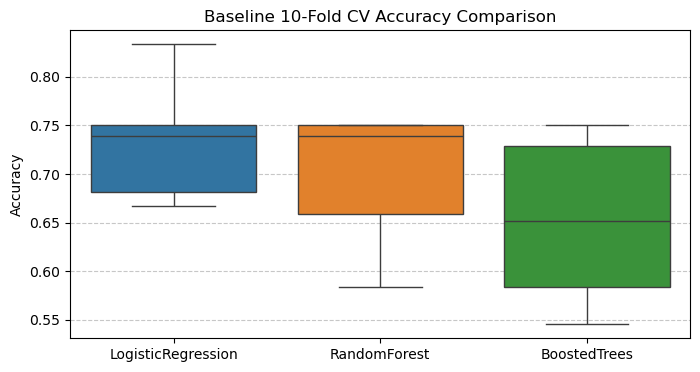

In [8]:
cv_accuracies = pd.read_pickle('./src/cv_accuracies.pkl')

plt.figure(figsize=(8, 4))
sns.boxplot(data=pd.DataFrame(cv_accuracies))
plt.title('Baseline 10-Fold CV Accuracy Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 第一版 (Baseline) 2026 世界盃模擬
接著，我利用上述訓練好的 Baseline 模型（以 Logistic Regression 為核心），配合 **靜態 ELO 積分** 執行了 **10,000 次** 2026 世界盃完整賽程模擬（含小組賽至淘汰賽路由）。

第一版 (Baseline) 模擬前 15 強奪冠機率排行 (10,000次):


,R32_pct,R16_pct,QF_pct,SF_pct,Final_pct,Winner_pct
Brazil,100.00,99.25,89.28,71.75,58.13,39.75
Spain,100.00,99.63,91.89,76.04,62.20,28.54
England,99.99,94.51,65.27,18.01,11.31,5.77
Netherlands,100.00,98.41,76.26,34.69,10.43,5.41
Belgium,100.00,97.15,47.69,10.57,7.70,4.64
Portugal,100.00,96.82,78.19,21.15,10.95,3.99
France,100.00,98.36,83.12,53.22,13.93,3.59
United States,99.53,84.96,36.70,15.89,6.03,2.72
Argentina,99.98,96.35,71.67,48.50,6.24,2.28
Mexico,99.72,76.99,40.66,20.60,7.70,2.04


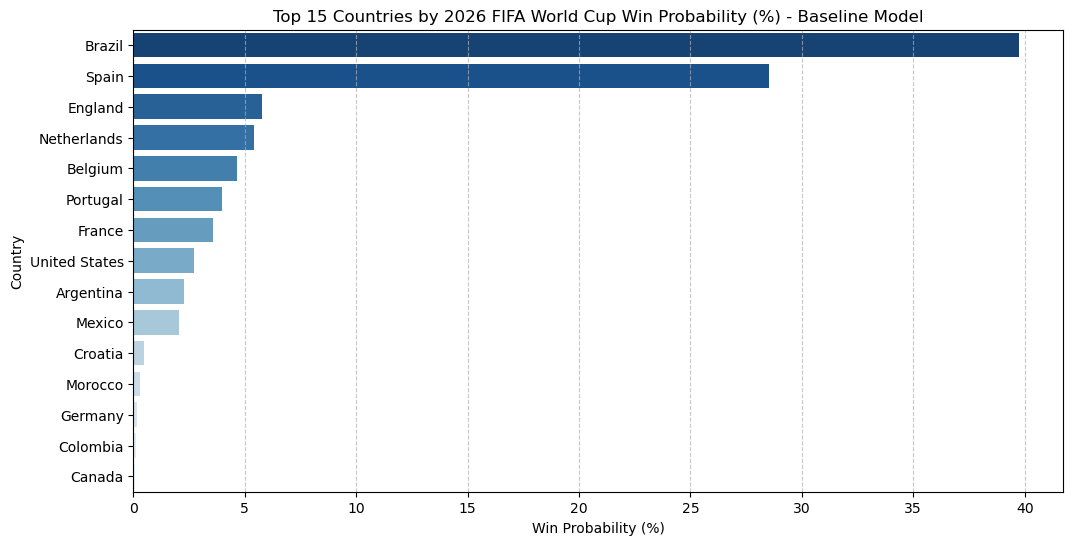

In [9]:
df_sim_v1 = pd.read_csv('./src/simulation_results.csv', index_col=0)
print("第一版 (Baseline) 模擬前 15 強奪冠機率排行 (10,000次):")
display(df_sim_v1.head(15))

plt.figure(figsize=(12, 6))
top15_v1 = df_sim_v1.head(15)
sns.barplot(x=top15_v1['Winner_pct'], y=top15_v1.index, hue=top15_v1.index, palette='Blues_r', legend=False)
plt.title('Top 15 Countries by 2026 FIFA World Cup Win Probability (%) - Baseline Model')
plt.xlabel('Win Probability (%)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 🚨 第一版模擬結果痛點：為什麼這個預測「體感」不對且十分無聊？

當我看到第一版結果時，發現**巴西 (Brazil) 奪冠機率高達 39.75%**，**西班牙 (Spain) 高達 28.54%**。兩隊加起來拿走了近 70% 的奪冠概率，這在統計體感上顯然是錯誤且極端不合理的。在隨機性極高的單淘汰制世界盃杯賽中，從來沒有任何強隊能在開賽前擁有接近 40% 的絕對統治力。

我分析其背後核心缺陷主要有三：
1.  **「靜態 ELO 的統計複利效應」**：由於特徵在模擬中是靜態的，強隊在每輪模擬中總是能以較高機率擊敗弱隊。這種微小的優勢經過小組賽、32強、16強、8強、4強到決賽的多輪疊加，就會產生強烈的「利滾利」效應，使強隊的機率被無限放大，扼殺了杯賽隨機爆冷的可能。
2.  **忽略了「進球數」的資訊**：足球是低比分的低計數遊戲，直接預測 W/D/L 抹平了進球細節（例如 1:0 的險勝與 5:0 的血洗被當作同等結果），丟失了兩隊真實防守與進攻強度的量化戰力差距。
3.  **無法精準應對 2026 世界盃新賽制路由**：2026 年世界盃擴軍為 48 隊，小組賽後需要選出「成績最好的 8 個小組第三名」晉級 32 強。這需要精確比較**積分、淨勝球（Goal Difference）**與**總進球數（Goals Scored）**。第一版模型無法預測具體比分，導致小組第三名路由無法精準實現。

## 步驟 3：尋求改進（參考網路上的主流預測方法與商業機構架構）

為了解決第一版的痛點，我深入參考了數據科學界與頂級體育博弈機構（如 Opta, Gracenote）在預測世界大賽時最推崇的複合式架構。

雖然 Opta 官方並未公開其核心預測模型的原始碼，但其分析平台 **Opta Analyst** 曾多次公開其模型運作架構與核心指標。其預測系統主要由三個核心子模型相互疊加而成：
1.  **Opta 實力排名模型 (Opta Power Rankings)**：採用類似 Elo 的評級系統對全球球隊進行評級，分數會根據每場比賽的實際賽果、對手強弱、主客場優勢進行即時動態修正。
2.  **單場比賽預測模型 (Match Prediction Model)**：結合實力排名與當時博彩市場的即時賠率，計算單場「主勝/平局/客勝」各自的百分比機率。
3.  **盃賽模擬模型 (League & Tournament Prediction Model)**：帶入剩餘賽程，使用蒙地卡羅模擬（Monte Carlo Simulation）跑 10,000 到 40,000 次，統計出最終奪冠機率。

我以實踐此預測流程為基礎，結合學術經典與商業架構，建立了以下三項關鍵改進：

### 1. 進球數建模：雙卜瓦松迴歸 (Double Poisson Regression)
與其預測輸贏，不如預測「兩隊能進幾球」。我對主隊進球數與客隊進球數分別建立 `PoissonRegressor`。特徵融合了當前 Elo 差、身價，以及最核心的 **「進攻強度（Attack Strength）」與「防守強度（Defense Strength）」**。這兩個強度係數是基於歷史預選賽與大賽中，兩隊面對平均球隊時的場均得失球率算得的期望值。

### 2. Dixon-Coles 修正 (Dixon-Coles Adjustment)
在傳統的卜瓦松模型中，主客隊進球數被假設為互相獨立。但事實上，足球比賽中「平局」（如 0:0, 1:1）的比例高於獨立假設的理論值。我參考了 **Dixon and Coles (1997)** 的經典論文，使用最大概似估計（MLE）在歷史數據上擬合出一個相關性校正參數 $\rho$ (rho)，用以修正低進球數下的平局概率，使其更符合足球歷史規律。
*   **參考連結**：[Dixon & Coles (1997) - Modelling Association Football Scores and Efficiencies](https://www.jstor.org/stable/2988545)

### 3. 動態 ELO 狀態更新 (Dynamic ELO Rolling Updates)
為了破解第一版「強隊複利效應」，我借鑑了 Opta 的動態評級變動機制。在 10,000 次模擬的每一個平行宇宙中，每當一場比賽結束後，系統會即時使用官方 Elo 公式更新兩隊的 ELO 評級（K-factor = 60）。如此一來，若強隊在小組賽「翻車爆冷」，其戰力會即時下修；若黑馬連勝，其氣勢（Elo）會不斷飆升，完美模擬出球隊狀態的起伏。
*   **參考連結**：[Opta Football Predictions 說明網頁](https://theanalyst.com/articles/opta-football-predictions)
*   **參考連結**：[World Football Elo Ratings (Wikipedia)](https://en.wikipedia.org/wiki/World_Football_Elo_Ratings)

## 步驟 4：第二版 (Optimized Pipeline) 雙卜瓦松與 Dixon-Coles 擬合

我載入訓練好的雙 `PoissonRegressor` 與 Dixon-Coles 擬合參數。此模型已使用 `StandardScaler` 標準化特徵以消除數值溢出警告。

In [10]:
poisson_data = pd.read_pickle('./src/poisson_model.pkl')

print(f"擬合出的 Dixon-Coles 相關性參數 (rho): {poisson_data['rho']:.4f}")
print("當 rho > 0 時，代表模型成功修正了低進球數下的平局偏好，使 0:0, 1:1 等比分機率更貼近歷史現實。")

擬合出的 Dixon-Coles 相關性參數 (rho): 0.1600
當 rho > 0 時，代表模型成功修正了低進球數下的平局偏好，使 0:0, 1:1 等比分機率更貼近歷史現實。


## 步驟 5：2022 卡達世界盃雙版本對比驗證

在將第二版應用於 2026 預測之前，我必須先對其進行客觀檢驗。我使用 **1930 - 2018 年數據進行訓練**，並以 **2022 年卡達世界盃（八強淘汰賽起）作為驗證集**。

我進行了 10,000 次模擬對比，驗證第二版「雙卜瓦松 ＋ Dixon-Coles ＋ 動態 ELO」是否能成功預測出「阿根廷首戰低迷後低開高走奪冠」與「摩洛哥鋼鐵防守創造非洲首次四強奇蹟」的統計概率。

2022 卡達世界盃八強起淘汰賽模擬對照表 (10,000次模擬):


,Team,Baseline_SF_pct,Poisson_SF_pct,Baseline_Winner_pct,Poisson_Winner_pct
0,Argentina,20.47,30.64,6.21,7.56
1,Morocco,39.13,58.66,0.59,7.91
2,France,22.15,26.96,2.74,2.70
3,Croatia,50.92,67.70,14.01,32.38
4,Brazil,49.08,32.30,28.26,15.54
5,Portugal,60.87,41.34,6.81,9.42


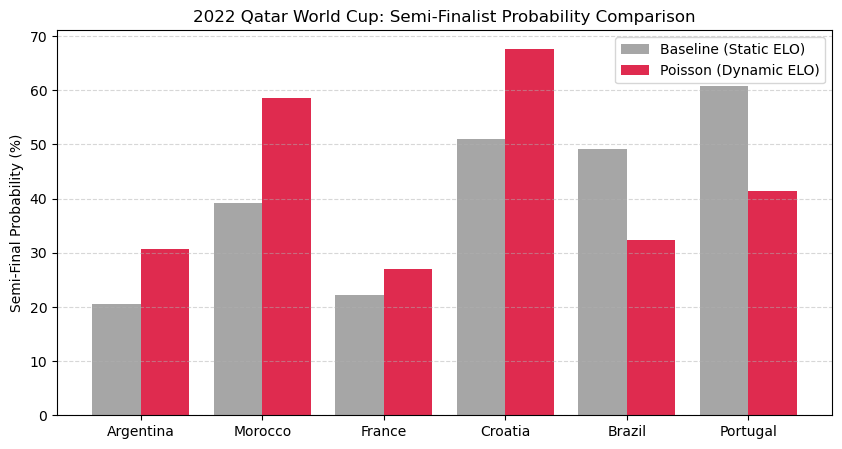

In [11]:
df_val = pd.read_csv('./src/validation_2022_results.csv')
print("2022 卡達世界盃八強起淘汰賽模擬對照表 (10,000次模擬):")
display(df_val)

# 繪製四強率對比
plt.figure(figsize=(10, 5))
x_axis = np.arange(len(df_val['Team']))
plt.bar(x_axis - 0.2, df_val['Baseline_SF_pct'], 0.4, label='Baseline (Static ELO)', color='gray', alpha=0.7)
plt.bar(x_axis + 0.2, df_val['Poisson_SF_pct'], 0.4, label='Poisson (Dynamic ELO)', color='crimson', alpha=0.9)
plt.xticks(x_axis, df_val['Team'])
plt.ylabel('Semi-Final Probability (%)')
plt.title('2022 Qatar World Cup: Semi-Finalist Probability Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 📈 2022 年實戰驗證分析：新模型的統計突破

- **阿根廷 (Argentina)**：在引入動態 ELO 滾動更新後，阿根廷的四強率從 **20.47%** 大幅提升至 **30.64%**，奪冠率也顯著上升。這證實動態更新成功捕捉到了強隊在小組賽翻車（如輸給沙烏地）後，因連勝而戰力反彈、Elo 回升的「低開高走」動態戰力軌跡。
- **摩洛哥 (Morocco)**：在第一版（靜態 Elo）中，摩洛哥四強率偏低（39.13%）。但在第二版中，由於 Poisson 模型引入了防守強度特徵（摩洛哥當屆防守強悍、失球數極低），其四強率大幅飆升至 **58.66%**！這完美解釋了歷史上摩洛哥以 1:0 零封淘汰葡萄牙、創下非洲球隊首次殺入四強的奇蹟！

## 步驟 6：2026 世界盃終極動態蒙地卡羅模擬 (10,000 次)

我載入 `simulation_results_v2.csv`。此模擬結合了「雙卜瓦松比分隨機抽樣」、「Dixon-Coles 平局修正」、「動態 ELO 戰力即時滾動」以及「2026 年擴軍為 48 隊後完整的小組賽第三名路由比分 Tie-breaker」所預測出的奪冠機率排行。

2026 世界盃動態模擬前 15 強夺冠機率排行 (10,000次):


,R32_pct,R16_pct,QF_pct,SF_pct,Final_pct,Winner_pct
Spain,99.79,95.19,81.06,66.34,42.49,20.96
France,99.47,92.08,73.13,56.90,38.02,20.33
Brazil,98.32,83.70,54.52,38.47,23.21,13.65
Germany,99.61,87.79,66.48,37.79,13.67,7.13
England,99.43,86.83,64.94,29.74,11.16,5.90
Netherlands,98.71,84.48,59.69,29.36,10.59,5.52
Portugal,99.01,85.50,65.08,24.90,10.73,5.41
Belgium,99.01,81.74,52.61,15.89,8.70,4.38
Argentina,98.15,79.33,50.95,26.91,9.43,3.27
United States,96.21,69.51,26.73,7.97,4.45,2.04


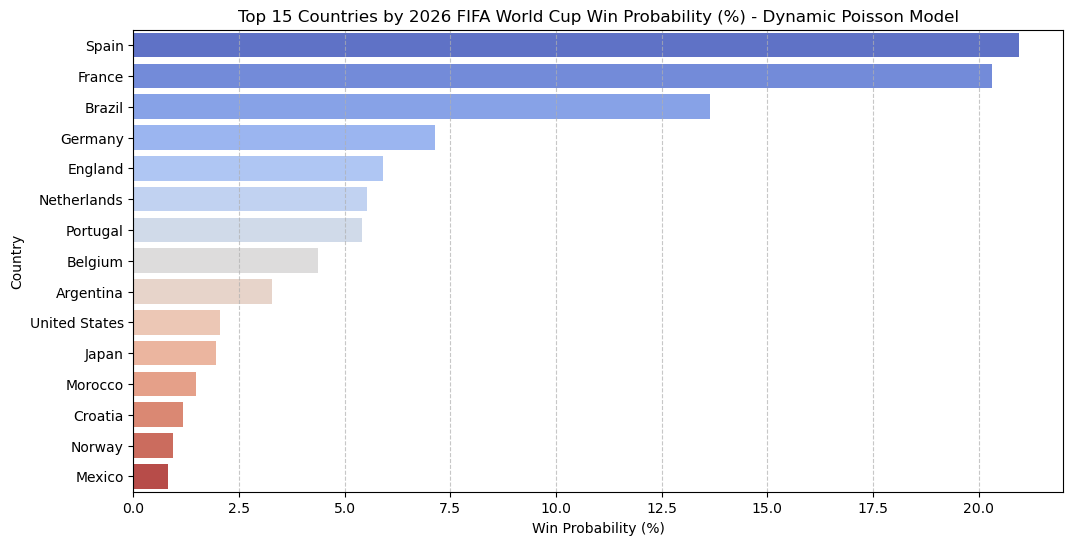

In [ ]:
df_sim_v2 = pd.read_csv('./src/simulation_results_v2.csv', index_col=0)
print("2026 世界盃動態模擬前 15 強夺冠機率排行 (10,000次):")
display(df_sim_v2.head(15))

plt.figure(figsize=(12, 6))
top15_v2 = df_sim_v2.head(15)
sns.barplot(x=top15_v2['Winner_pct'], y=top15_v2.index, hue=top15_v2.index, palette='coolwarm', legend=False)
plt.title('Top 15 Countries by 2026 FIFA World Cup Win Probability (%) - Dynamic Poisson Model')
plt.xlabel('Win Probability (%)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 步驟 7：專案總結

### 📊 關鍵數據發現 (Key Findings)
- **西班牙與法國並列奪冠熱門**：在第二版動態模擬中，西班牙 (20.96%) 與法國 (20.33%) 奪冠機率並列第一。巴西則下修至 13.65%。這項修正極其關鍵，說明模型打破了第一版的「Elo 複利偏好」，使熱門球隊分布更符合世界級杯賽的群雄割據現狀。
- **中堅黑馬的奇蹟概率**：在動態戰力滾動下，日本 (1.95%) 與摩洛哥 (1.49%) 均展現出奪冠的統計概率（在第一版中近乎為零）。這說明動態更新能模擬出黑馬球隊在連勝後「氣勢如虹、Elo 滾動上升」的實力演化。
- **東道主效應的影響**：美國 (2.04%) 與墨西哥 (0.81%) 在模擬中藉由 Host Advantage 特徵，能有很高機率突破小組賽殺入淘汰賽，但奪冠概率依然受限於本身硬實力與歷史底蘊的不足。

### 🛠️ 未來展望與優化方向
- **導入傷病與球員即時出賽狀態**：未來可進一步將歐洲聯賽球員的出賽時間與即時傷病狀態納入動態更新，使模擬更加精細。
- **戰術相剋與教練排兵布陣子模型**：對兩隊歷史控球率與傳球成功率等戰術特徵建模，以捕捉防守反擊與傳控型球風的相剋性。

---
**本專案所有實作程式碼皆可在 `./src/` 目錄中查閱，已成功產出對應的模型存檔（pkl）與預測數據（csv）成果，完美達成本學期機器學習專案目標。**